# Plane-wave Expansion Twistronix

In [2]:
from math import sqrt
import cmath
import numpy as np
import ase
from ase import Atoms
import scipy
from scipy.constants import hbar,pi
import matplotlib.pyplot as plt
from tqdm import tqdm

# %matplotlib ipykernel

In [ ]:
# Global vars

# Number of Miller indices
N=1
Nvecs = 3*N

# Moiré super cell
a0 = 2.46 # Agstrm this is standard lattice cst of graphene
am = a0*Nvecs # would be the lattice cst of Moiree graphene
theta=a0/am * 180/pi

t = 2.7#eV
vf = 3/2 * a0 * t #eV.Ang, fermi velocity
# waa = 0.090 # eV
# wab = 0.117 # eV
# waa = 0;#to force delta(potential) = 0
# wab = 0;#to force delta(potential) = 0--> useful for plotting just hkin
hbar = 1

iCell=4*np.pi/(np.sqrt(3)*am)*np.array(([[1/2,np.sqrt(3)/2],[-1/2,np.sqrt(3)/2]]))

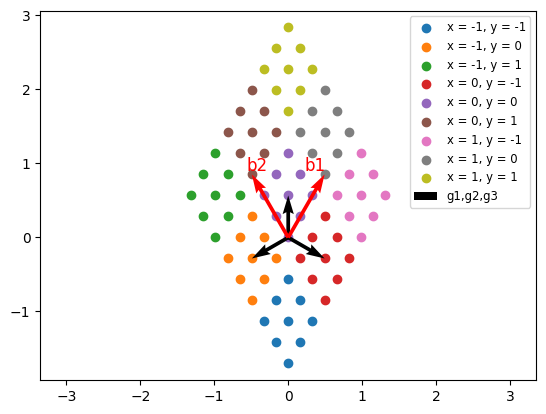

In [4]:
# calculate G where G_ij = i*iCell[0,:] + j * iCell[1, :], i,j Miller indices
# For i and j in 0 to Nvecs-1, we have a permutation resulting in Nvecs**2 rows

# G = np.tile(iCell[0,:] , (Nvecs**2, 1)) * np.repeat(np.arange(0,Nvecs),Nvecs)[:,np.newaxis] \
#      + np.tile(iCell[1,:] , (Nvecs**2, 1)) * np.tile(np.arange(0,Nvecs),Nvecs)[:,np.newaxis] # Second term og G_ij

G = []
for i in range(Nvecs):
    for j in range(Nvecs):
        G.append(i/3*iCell[0] + j/3 * iCell[1])
G= np.array(G)

#plot the g vectors versus the G, 
g1 = np.array([0, 4*pi/(3*am)])
g2 = np.array([(-2*pi)/(sqrt(3)*am), (-2*pi)/(3*am)])
g3 = np.array([(2*pi)/(sqrt(3)*am), (-2*pi)/(3*am)])

#good to do everytime check the array
#plot all the nearby G displaced by b1,b2
for x in range(-1, 2):
    for y in range(-1, 2):
       G2 = G + x * iCell[0] + y * iCell[1]
       plt.scatter(G2.T[0],G2.T[1],label=f"x = {x}, y = {y}")
plt.quiver(0, 0, g1[0],g1[1],angles='xy', scale_units='xy', scale=1, color='black',label = "g1,g2,g3")
plt.quiver(0, 0, g2[0],g2[1],angles='xy', scale_units='xy', scale=1, color='black')
plt.quiver(0, 0, g3[0],g3[1],angles='xy', scale_units='xy', scale=1, color='black')
#plot the reciprocal lattice vectors b1,b2
plt.quiver(0, 0, iCell[0,0], iCell[0,1],angles='xy', scale_units='xy', scale=1, color='red')
plt.text(iCell[0,0]*0.75, iCell[0,1]*1.05, 'b1', color='red', fontsize=12, ha='center')
plt.quiver(0, 0, iCell[1,0], iCell[1,1], angles='xy', scale_units='xy', scale=1, color='red')
plt.text(iCell[1,0]*0.85, iCell[1,1]*1.05, 'b2', color='red', fontsize=12, ha='center')
plt.legend(fontsize="small")
plt.axis('equal')
plt.savefig('latticeG.png')
plt.show()


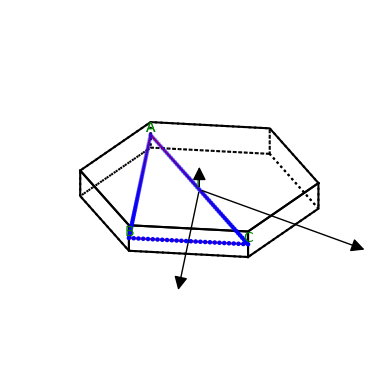

In [ ]:
from ase import Atoms
from ase.dft.kpoints import bandpath
import numpy as np
import matplotlib.pyplot as plt

#new path 
a = 2.46  # lattice constant in angstroms
c = 15.0  # vacuum spacing in the z direction for a monolayer
newCell = [
    [ a, 0, 0],
    [-a / 2, np.sqrt(3) / 2 * a, 0],
    [0, 0, c]
]
# Create an Atoms object for graphene with this cell
graphene = Atoms(cell=newCell, pbc=True)  
points = {
    'A': [-1/3, -1/3, 0],
    'Γ': [0, 0, 0],
    'B': [2/3, -1/3, 0],
    'C': [1/3, 1/3, 0],
}

# path in the cell
path_sequence = "AΓCBA"
#create band path
band_path = bandpath(path=path_sequence, cell=graphene.cell, special_points=points, npoints = 120)

band_path.plot()
plt.show()
# Get kpoints along the path
kpts_lin, sympoint_name, labels = band_path.get_linear_kpoint_axis()
kpts=band_path.kpts[:,:2].dot(iCell)
labels = ["K","Γ","K'","K''","K"]

In [6]:
epsilon = 1e-6
g1Min_indx = []
g2Min_indx = []
g3Min_indx = []
g1Plus_indx = []
g2Plus_indx = []
g3Plus_indx = []

for x in range(-1, 2):
    for y in range(-1, 2):
        Gsq=G[:,None]-G[None,:] + x*iCell[0] + y*iCell[1]

        indices = np.where(np.linalg.norm(Gsq - g1[None, None, :], axis=-1) < epsilon)
        if indices[0].size > 0:  # Check if there's at least one matching index
            g1Min_indx.append(indices)

        indices = np.where(np.linalg.norm(Gsq - g2[None, None, :], axis=-1) < epsilon)
        if indices[0].size > 0:  # Check if there's at least one matching index
            g2Min_indx.append(indices)

        indices = np.where(np.linalg.norm(Gsq - g3[None, None, :], axis=-1) < epsilon)
        if indices[0].size > 0:  # Check if there's at least one matching index
            g3Min_indx.append(indices)
        
        indices = np.where(np.linalg.norm(Gsq + g1[None, None, :], axis=-1) < epsilon)
        if indices[0].size > 0:  # Check if there's at least one matching index
            g1Plus_indx.append(indices)

        indices = np.where(np.linalg.norm(Gsq + g2[None, None, :], axis=-1) < epsilon)
        if indices[0].size > 0:  # Check if there's at least one matching index
            g2Plus_indx.append(indices)
        
        indices = np.where(np.linalg.norm(Gsq + g3[None, None, :], axis=-1) < epsilon)
        if indices[0].size > 0:  # Check if there's at least one matching index
            g3Plus_indx.append(indices)
        

# print(g1Min_indx)
# print(g2Min_indx)
# print(g3Min_indx)
# print(g1Plus_indx)
# print(g2Plus_indx)
# print(g3Plus_indx)

g1Min_indx= (np.concatenate([x[0] for x in g1Min_indx]),  np.concatenate([x[1] for x in g1Min_indx]))
print(g1Min_indx)
g2Min_indx= (np.concatenate([x[0] for x in g2Min_indx]),  np.concatenate([x[1] for x in g2Min_indx]))
print(g2Min_indx)
g3Min_indx= (np.concatenate([x[0] for x in g3Min_indx]),  np.concatenate([x[1] for x in g3Min_indx]))
print(g3Min_indx)
g1Plus_indx= (np.concatenate([x[0] for x in g1Plus_indx]),  np.concatenate([x[1] for x in g1Plus_indx]))
print(g1Plus_indx)
g2Plus_indx= (np.concatenate([x[0] for x in g2Plus_indx]),  np.concatenate([x[1] for x in g2Plus_indx]))
print(g2Plus_indx)
g3Plus_indx= (np.concatenate([x[0] for x in g3Plus_indx]),  np.concatenate([x[1] for x in g3Plus_indx]))
print(g3Plus_indx)

(array([4, 5, 7, 8, 3, 6, 1, 2, 0]), array([0, 1, 3, 4, 2, 5, 6, 7, 8]))
(array([4, 5, 7, 8, 3, 6, 1, 2, 0]), array([0, 1, 3, 4, 2, 5, 6, 7, 8]))
(array([4, 5, 7, 8, 3, 6, 1, 2, 0]), array([0, 1, 3, 4, 2, 5, 6, 7, 8]))
(array([8, 6, 7, 2, 5, 0, 1, 3, 4]), array([0, 1, 2, 3, 6, 4, 5, 7, 8]))
(array([8, 6, 7, 2, 5, 0, 1, 3, 4]), array([0, 1, 2, 3, 6, 4, 5, 7, 8]))
(array([8, 6, 7, 2, 5, 0, 1, 3, 4]), array([0, 1, 2, 3, 6, 4, 5, 7, 8]))


In [7]:
#function to find the unique values in between gi, gj
def find_unique_pairs(g1, g2):
    # Create a set of pairs from g1 for quick lookup
    g1_pairs = set(zip(g1[0], g1[1]))
    # Lists to store unique pairs for g2prime
    g2prime_x = []
    g2prime_y = []
    # Iterate over each pair in g2
    for x, y in zip(g2[0], g2[1]):
        pair = (x, y)
        
        # Check if the pair is not in g1_pairs
        if pair not in g1_pairs:
            g2prime_x.append(x)
            g2prime_y.append(y)
    
    # Convert lists to arrays and create the final tuple
    g2prime = (np.array(g2prime_x), np.array(g2prime_y))

    return g2prime

So the mark Delta0g2,Delta0g3 are empty since all of the information is contained within Delta0g1, and the scattering is redundant witht the other two. So w only take the effects of Delta0g1 to calculate the Delta0g1 to calculate Delta0. In some other cases the Delta0g2,Delta0g3 may not be empty but for this case N = 1 Nvec = 3 they are empty.
We can now do the same for the Deltax Deltay

In [8]:
#-----A bit more optimized code----THis is the updated fucntion where we find the unique indices see V5 for old version
def calculateDeltas(Nvecs,kz):
    

    # Initialize complex zero matrices
    def initialize_tmp_arrays(size):
        return [np.zeros((size, size), dtype=np.complex128) for _ in range(3)]

    # Populate tmp arrays with the appropriate values
    def populate_tmp_arrays(min_indices, plus_indices, coef1, coef2, coef3=0):
        tmp01, tmp11, tmp21 = initialize_tmp_arrays(Nvecs**2)
        tmp02, tmp12, tmp22 = initialize_tmp_arrays(Nvecs**2)

        for i, j in zip(*min_indices):
            tmp01[i, j] = coef1 * cmath.exp(1j * kz)
            tmp11[i, j] = coef2 * cmath.exp(1j * kz)
            tmp21[i, j] = coef3 * cmath.exp(1j * kz)

        for i, j in zip(*plus_indices):
            tmp02[i, j] = coef1 * cmath.exp(-1j * kz)
            tmp12[i, j] = coef2 * cmath.exp(-1j * kz)
            tmp22[i, j] = coef3 * cmath.exp(-1j * kz)

        return tmp01 + tmp02, tmp11 + tmp12, tmp21 + tmp22

    # Coefficients
    coef_waa = 4 * pi**2 * waa
    coef_wab = 2 * pi**2 * wab
    coef_sqrt3_wab = 2 * pi**2 * sqrt(3) * wab

    
    
    # Final Delta values

    #Generate Delta matricces 0,x using only unqiue scattering for g1,g2,g3 see example above
    Delta0g1, Delta1g1, _ = populate_tmp_arrays(g1Min_indx, g1Plus_indx, coef_waa, coef_wab)
    Delta0g2, Delta1g2, _ = populate_tmp_arrays(find_unique_pairs(g1Min_indx,g2Min_indx), find_unique_pairs(g1Plus_indx,g2Plus_indx), coef_waa, -coef_wab, coef_sqrt3_wab)
    Delta0g3, Delta1g3, _ = populate_tmp_arrays(find_unique_pairs(find_unique_pairs(g1Min_indx,g2Min_indx),find_unique_pairs(g1Min_indx,g3Min_indx)), find_unique_pairs(find_unique_pairs(g1Plus_indx,g2Plus_indx),find_unique_pairs(g1Plus_indx,g3Plus_indx)), coef_waa, -coef_wab, -coef_sqrt3_wab)
    #then calculate the Delta0 and Deltax
    Delta0 = Delta0g1 + Delta0g2 + Delta0g3
    DeltaX = Delta1g1 + Delta1g2 + Delta1g3

    #HEre we do the same with just g2,g3 since no effect with g1
    _, _, Delta2g2 = populate_tmp_arrays(g2Min_indx, g2Plus_indx, coef_waa, -coef_wab, coef_sqrt3_wab)
    _, _, Delta2g3 = populate_tmp_arrays(find_unique_pairs(g2Min_indx,g3Min_indx),find_unique_pairs(g2Plus_indx,g3Plus_indx), coef_waa, -coef_wab, -coef_sqrt3_wab)
   
    DeltaY = Delta2g2 + Delta2g3#Delta2g1 always zero 

    return (Delta0,DeltaX,DeltaY)

We see that Delta0g2,Delta0g3 are 0 so  it good and ,Delta0 == Delta0g1 so good.\
Same for Deltax = Delta1g1 and Delta1g2,Delta1g3 = 0 becasue saem scattering as g1.\
Finally DeltaY = Delta2g2 and Delta2g3 = 0 since same scattering for g2,g3

In [9]:
# Generate hamiltonian
def genHamiltonian(Nvecs, G, K,kz):
    H = np.zeros((2*Nvecs**2, 2*Nvecs**2), dtype=np.complex128)  # Pre-allocate H
    #size 2N^2 x 2N^2 since each element 2x2 matrices

    # --------------Add Hkin matrix----------------
    # Upper diag
    UpperDiag = G[:,0] - 1j * G[:,1]  + K[0] - 1j *K[1]
    # Lower diag
    LowerDiag = G[:,0] + 1j * G[:,1]  + K[0] + 1j *K[1]
    # Select diagonal terms according to 2x2 matrix indexing
    evenIndex = np.arange(0, 2*Nvecs**2, step=2)
    oddIndex = np.arange(1, 2*Nvecs**2, step=2)

    
    #Fill upper   
    H[evenIndex,oddIndex] = hbar * vf * UpperDiag
    #Fill lower
    H[oddIndex,evenIndex] = hbar * vf * LowerDiag

   #--------------Cacluating the potential Delta--------------
    Delta0, DeltaX, DeltaY = calculateDeltas(Nvecs,kz)
    #put deltas in the hamiltonian h
    k = 0
    for i in range(Nvecs**2):
        m = 0
        for j in range(Nvecs**2):
            if i != j:
                H[k,m] = Delta0[i,j]
                H[k+1,m+1] = Delta0[i,j]
                H[k,m+1] = DeltaX[i,j] - 1j * DeltaY[i,j]
                H[k+1,m] = DeltaX[i,j] + 1j * DeltaY[i,j]
            m = m + 2
        k = k + 2
    
    return H

    

### Below we do calculations with no potential i.e. just hkin

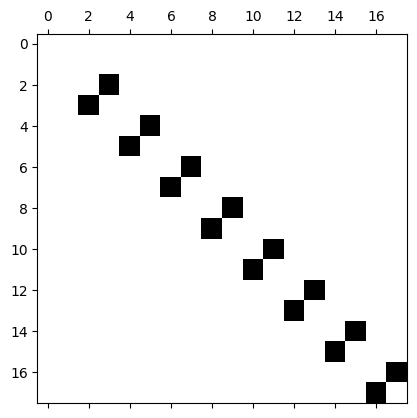

In [10]:
waa = 0.0 # eV
wab = 0.0 # eV
plt.figure()

h=genHamiltonian(Nvecs=Nvecs,G=G,K=[0,0],kz = 0)
plt.spy(h)

100%|██████████| 120/120 [00:00<00:00, 5491.30it/s]


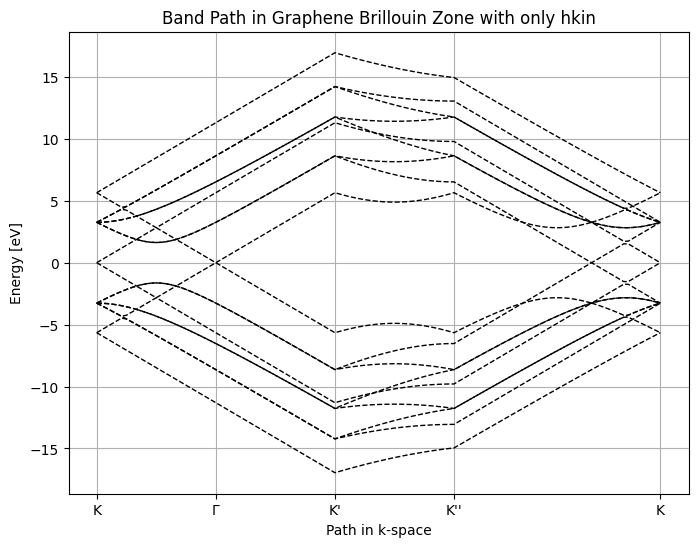

In [ ]:
# Calculate energy

#matrix of energy for each band
Emat = np.zeros((band_path.kpts.shape[0], 2*Nvecs**2))

k = 0
for kpt in tqdm(kpts):
    [E, u] = np.linalg.eigh(genHamiltonian(Nvecs, G, kpt,kz = 0))
    Emat[k,:] = np.sort(E)
    k = k + 1

plt.figure(figsize=(8, 6))

# Plot each band (each column in Emat represents a band along the k-point path)
for band in range(2 * Nvecs**2):
    plt.plot(kpts_lin, Emat[:, band],'--', color='black', lw=1)
     # Simple plot along y=0 for visualization

plt.xticks(sympoint_name,labels)       # Label the high-symmetry points

# Add labels and grid for clarity
plt.xlabel("Path in k-space")
plt.ylabel("Energy [eV]")  # Typically energy would be here if plotting band structure
plt.title("Band Path in Graphene Brillouin Zone with only hkin")
plt.grid(True)

# Show the plot
#plt.savefig('hkin_.png')
plt.show()



### Below we do the calculations taking into account the effects of nearby repeating cells, x,y in (-1,1)

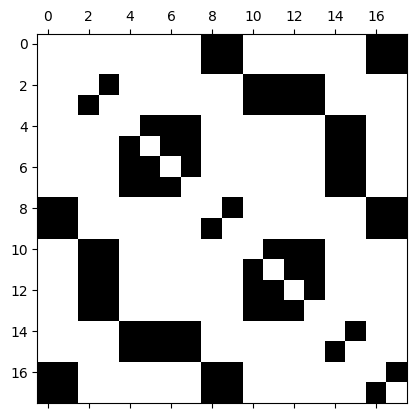

In [12]:
waa = 0.090 # eV
wab = 0.117 # eV
plt.figure()

h=genHamiltonian(Nvecs=Nvecs,G=G,K=[0,0],kz = 0)
plt.spy(h)

In [13]:
# Calculate energy

#matrix of energy for each band
Emat = np.zeros((band_path.kpts.shape[0], 2*Nvecs**2))

k = 0
for kpt in tqdm(kpts):
    [E, u] = np.linalg.eigh(genHamiltonian(Nvecs, G, kpt,kz = 0))
    Emat[k,:] = np.sort(E)
    k = k + 1


100%|██████████| 120/120 [00:00<00:00, 1669.49it/s]


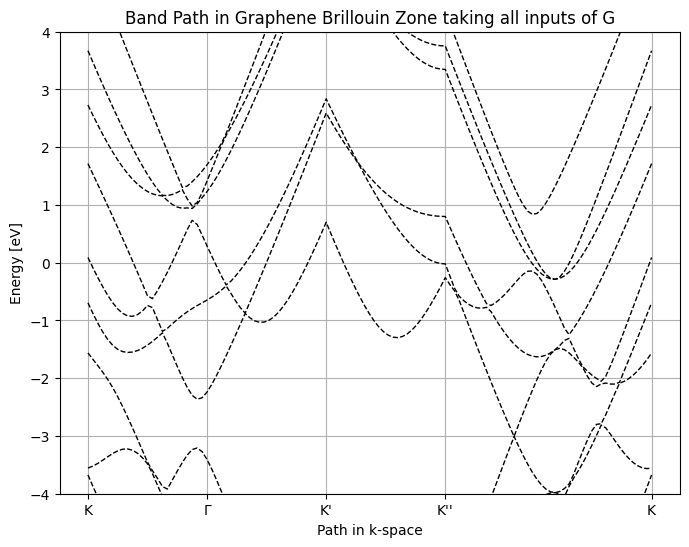

In [ ]:
plt.figure(figsize=(8, 6))

# Plot each band (each column in Emat represents a band along the k-point path)
for band in range(2 * Nvecs**2):
    plt.plot(kpts_lin, Emat[:, band],'--', color='black', lw=1)

plt.xticks(sympoint_name,labels)       # Label the high-symmetry points

# Add labels and grid for clarity
plt.xlabel("Path in k-space")
plt.ylabel("Energy [eV]")  # Typically energy would be here if plotting band structure
plt.title("Band Path in Graphene Brillouin Zone taking all inputs of G")
plt.grid(True)
plt.ylim((-4,4))
# Show the plot
#plt.savefig('bands_N3.png')
plt.show()

### Below we do the calculations without taking into account the effects of nearby repeating cells

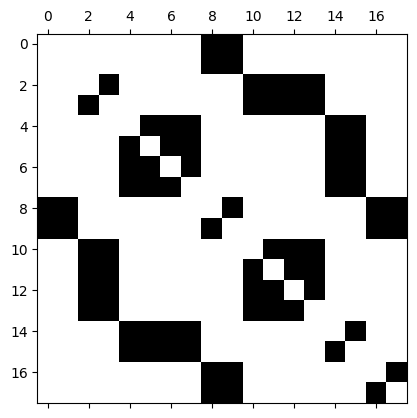

In [15]:
#---------Not taking into account x,y dispalcement i.e. (x = 0,y =0)----------
epsilon = 1e-6;#error when calculating the dirac so to be considered 0

Gsq=G[:,None]-G[None,:]

#We create the delta function for both +- g_j see paper
g1Min_indx=np.where(np.linalg.norm(Gsq-g1[None,None,:],axis=-1)<epsilon)
g2Min_indx=np.where(np.linalg.norm(Gsq-g2[None,None,:],axis=-1)<epsilon)
g3Min_indx=np.where(np.linalg.norm(Gsq-g3[None,None,:],axis=-1)<epsilon)

g1Plus_indx=np.where(np.linalg.norm(Gsq+g1[None,None,:],axis=-1)<epsilon)
g2Plus_indx=np.where(np.linalg.norm(Gsq+g2[None,None,:],axis=-1)<epsilon)
g3Plus_indx=np.where(np.linalg.norm(Gsq+g3[None,None,:],axis=-1)<epsilon)

# print(g1Min_indx)
# print(g2Min_indx)
# print(g3Min_indx)
# print(g1Plus_indx)
# print(g2Plus_indx)
# print(g3Plus_indx)

waa = 0.090 # eV
wab = 0.117 # eV
plt.figure()
kz = 0
h=genHamiltonian(Nvecs,G,K =[0,0],kz = 0)
plt.spy(h)

In [16]:
# Calculate energy

#matrix of energy for each band
Emat = np.zeros((band_path.kpts.shape[0], 2*Nvecs**2))

k = 0
for kpt in tqdm(kpts):
    [E, u] = np.linalg.eigh(genHamiltonian(Nvecs, G, kpt,kz = 0))
    Emat[k,:] = np.sort(E)
    k = k + 1


100%|██████████| 120/120 [00:00<00:00, 3347.85it/s]


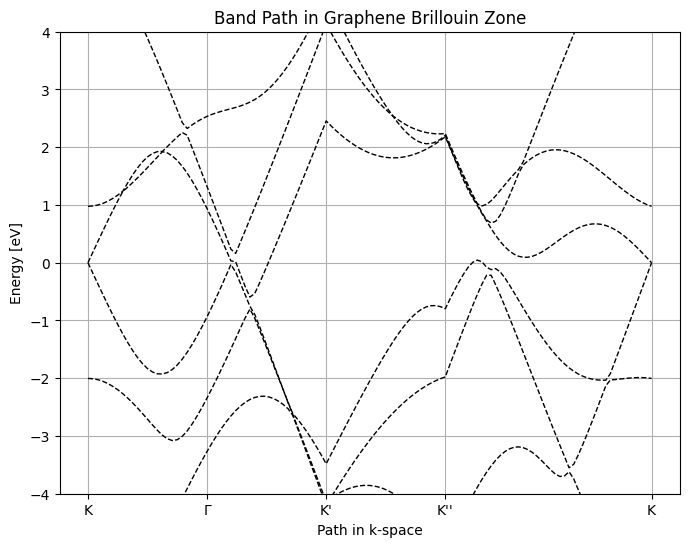

In [18]:
plt.figure(figsize=(8, 6))

# Plot each band (each column in Emat represents a band along the k-point path)
for band in range(2 * Nvecs**2):
    plt.plot(kpts_lin, Emat[:, band],'--', color='black', lw=1)

plt.xticks(sympoint_name,labels)       # Label the high-symmetry points

# Add labels and grid for clarity
plt.xlabel("Path in k-space")
plt.ylabel("Energy [eV]")  # Typically energy would be here if plotting band structure
plt.title("Band Path in Graphene Brillouin Zone")
plt.grid(True)
plt.ylim((-4,4))
# Show the plot
plt.show()

### We can now do the calculations along the k_z axis
Here we take kx,ky = (0,0) and kz[-pi,pi] see new notebook